In [14]:
# Imports, as always...
import os
import numpy as np
import pandas as pd
from typing import List
from tqdm import tqdm

# Circuitry.
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import random_unitary
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector

# Braket.
from qiskit_braket_provider import BraketProvider
from braket.tracking import Tracker
from braket.aws.aws_quantum_task import AwsQuantumTask
from qiskit.visualization import plot_histogram
from qiskit.qasm3 import loads

# Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

# Circuit Building

In [2]:
# Function to generate a circuit using the brickwork architecture.
def generate_brickwork_circuit(n : int, d : int, rng = None):
    # A brickwork circuit only really makes sense with at least 3 qubits.
    assert n > 2, 'Brickwork architectures require at least 3 qubits to be worth the bother.'

    # Instantiate a circuit object.
    circuit = QuantumCircuit(n)

    # Iteratively adding layers of bricks.
    for l in range(d):
        # Even layer arrangement.
        if l % 2 == 0:
            for i in range(n // 2):
                # Sample a Haar random unitary from U(4).
                circuit.append(
                    UnitaryGate(random_unitary(4, rng), label='$U_{' + str(l) + str(i) + '}$'),
                    [2*i, 2*i + 1]
                )

        # Odd layer arrangement.
        else:
            for i in range(1, n //2 + 1):
                # And again.
                circuit.append(
                    UnitaryGate(random_unitary(4, rng), label='$U_{' + str(l) + str(i) + '}$'),
                    [2*i - 1, 2*i]
                )

    return circuit

# Demo.
demo_circuit = generate_brickwork_circuit(n=5, d=4, rng=np.random.default_rng(seed=42))
demo_circuit.measure_all()
demo_circuit.draw()

┌───────────┐             ┌───────────┐              ░ ┌─┐            
   q_0: ┤0          ├─────────────┤0          ├──────────────░─┤M├────────────
        │  $U_{00}$ │┌───────────┐│  $U_{20}$ │┌───────────┐ ░ └╥┘┌─┐         
   q_1: ┤1          ├┤0          ├┤1          ├┤0          ├─░──╫─┤M├─────────
        ├───────────┤│  $U_{11}$ │├───────────┤│  $U_{31}$ │ ░  ║ └╥┘┌─┐      
   q_2: ┤0          ├┤1          ├┤0          ├┤1          ├─░──╫──╫─┤M├──────
        │  $U_{01}$ │├───────────┤│  $U_{21}$ │├───────────┤ ░  ║  ║ └╥┘┌─┐   
   q_3: ┤1          ├┤0          ├┤1          ├┤0          ├─░──╫──╫──╫─┤M├───
        └───────────┘│  $U_{12}$ │└───────────┘│  $U_{32}$ │ ░  ║  ║  ║ └╥┘┌─┐
   q_4: ─────────────┤1          ├─────────────┤1          ├─░──╫──╫──╫──╫─┤M├
                     └───────────┘             └───────────┘ ░  ║  ║  ║  ║ └╥┘
meas: 5/════════════════════════════════════════════════════════╩══╩══╩══╩══╩═
                                                                0  1  2  3  4

# Device Selecting

In [3]:
# Set region.
# IonQ and QuEra are on us-east-1, IQM is on eu-north-1, and Rigetti is on us-west-1.
os.environ['AWS_REGION'] = 'us-east-1'

In [4]:
# What's online at the moment?
provider = BraketProvider()
provider.backends(statuses=['ONLINE'])

[BraketBackend[Ankaa-3],
 BraketBackend[Forte 1],
 BraketBackend[Forte Enterprise 1],
 BraketBackend[Garnet],
 BraketBackend[SV1],
 BraketBackend[TN1],
 BraketBackend[dm1]]

In [5]:
# Getting a device.
qpu = provider.get_backend('Garnet')
print(qpu)

BraketBackend[Garnet]


# Data Generating

In [6]:
# Generating data.
def depth_varied_routine(
    n: int,
    ds: List[int],
    n_circuits: int,
    device,
    n_shots: int = 128,
    save_path = None,
    verbose: bool = False
) -> pd.DataFrame:
    # Dataframe to hold metadata.
    metadata_df = pd.DataFrame(columns=['n', 'd', 'circuit_seed', 'n_shots', 'device', 'task_id'])
    if save_path:
        metadata_df.to_csv(save_path, index=False) # Writing headers.

    # Start tracking costs.
    t = Tracker().start()

    seed = 0
    for d in (tqdm(ds, desc='Depths') if verbose else ds):
        for _ in range(n_circuits):
            # Next seed.
            seed += 1

            # Build the experiment circuit.
            experiment_circuit = generate_brickwork_circuit(n, d, np.random.default_rng(seed))
            experiment_circuit.measure_all()

            # Queue (and run) task.
            qpu_task = device.run(experiment_circuit, shots=n_shots)

            # Store metadata.
            run_metadata_df = pd.DataFrame({
                'n' : [n],
                'd' : [d],
                'circuit_seed' : [seed],
                'n_shots' : [n_shots],
                'device' : [device.name],
                'task_id' : [qpu_task.task_id()]
            })

            # Add to the overall results.
            metadata_df = pd.concat([metadata_df, run_metadata_df], ignore_index=True)

            # Save as we go (appending to file).
            if save_path:
                run_metadata_df.to_csv(save_path, mode='a', header=False, index=False)

    # Calculate costs.
    print(f'Total estimated cost: {t.qpu_tasks_cost() + t.simulator_tasks_cost():.3f} USD')

    # Return metadata (results to be collected from AWS using task_id).
    return metadata_df

In [7]:
metadata_df = depth_varied_routine(
    n=5,
    ds=[5, 10, 15, 20, 25],
    n_circuits=500,
    device=qpu,
    n_shots=512,
    save_path='./data/depth-varied/Garnet.csv',
    verbose=True
)

metadata_df

Depths: 100%|██████████| 5/5 [26:20<00:00, 316.06s/it]


Total estimated cost: 2606.000 USD


,n,d,circuit_seed,n_shots,device,task_id
0,5,5,1,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
1,5,5,2,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
2,5,5,3,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
3,5,5,4,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
4,5,5,5,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
...,...,...,...,...,...,...
2495,5,25,2496,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
2496,5,25,2497,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
2497,5,25,2498,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
2498,5,25,2499,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...


In [30]:
# For some inexplicable reason, Aria-1 and Ankaa-3 don't follow the same naming format.
# So change that manually...
if False:
    metadata_df.replace({'Aria 1' : 'Aria-1'}, inplace=True)
    metadata_df.to_csv('data/depth-varied/Aria-1.csv', index=False)
    
metadata_df

,n,d,circuit_seed,n_shots,device,task_id
0,5,5,1,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
1,5,5,2,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
2,5,5,3,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
3,5,5,4,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
4,5,5,5,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
...,...,...,...,...,...,...
695,5,10,696,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
696,5,10,697,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
697,5,10,698,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
698,5,10,699,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...


Matplotlib is building the font cache; this may take a moment.


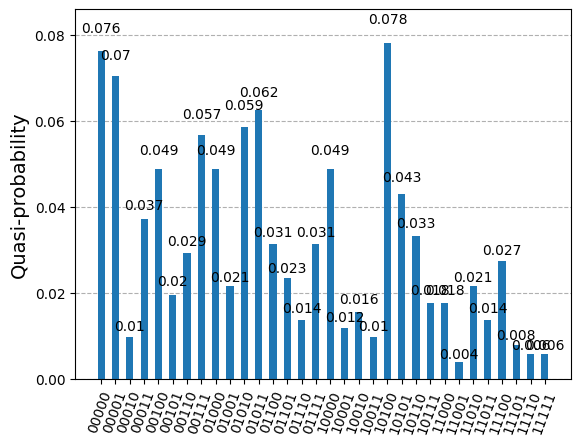

In [8]:
retrieved_task = AwsQuantumTask(arn=metadata_df.iloc[0]['task_id'])
plot_histogram(retrieved_task.result().measurement_probabilities)

# Data Reading

In [31]:
metadata_df = pd.read_csv('./data/depth-varied/Aria-1.csv')
metadata_df

,n,d,circuit_seed,n_shots,device,task_id
0,5,5,1,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
1,5,5,2,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
2,5,5,3,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
3,5,5,4,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
4,5,5,5,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
...,...,...,...,...,...,...
695,5,10,696,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
696,5,10,697,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
697,5,10,698,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...
698,5,10,699,512,Aria-1,arn:aws:braket:us-east-1:745438739765:quantum-...


In [5]:
# Reading in data, using the task_id column of the given dataframe.
def read_data_to_frame(
    metadata_df: pd.DataFrame
) -> pd.DataFrame:
    # Create copy.
    df = metadata_df.copy()

    # Assuming a fixed n -- I think it's cleaner.
    n = int(df.iloc[0]['n'])

    # Keeping a dataframe for measurement outcome probabilities.
    df[['x' + format(i, f'0{n}b') for i in range(2 ** n)]] = 0

    for i in tqdm(range(len(metadata_df))):
        # Get the task ID.
        task_id = metadata_df.iloc[i]['task_id']

        # Retrieve the task from AWS.
        retrieved_task = AwsQuantumTask(arn=task_id)

        # Translate the entries of the outcome distribution into the DataFrame.
        for state, prob in retrieved_task.result().measurement_probabilities.items():
            df.loc[i, 'x' + str(state)] = prob

    return df

In [7]:
data_df = read_data_to_frame(metadata_df)
data_df

100%|██████████| 700/700 [25:38<00:00,  2.20s/it]


,n,d,circuit_seed,n_shots,device,task_id,x00000,x00001,x00010,x00011,...,x10110,x10111,x11000,x11001,x11010,x11011,x11100,x11101,x11110,x11111
0,5,5,1,512,Aria 1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.060547,0.146484,0.007812,0.025391,...,0.031250,0.013672,0.007812,0.003906,0.017578,0.001953,0.035156,0.019531,0.003906,0.003906
1,5,5,2,512,Aria 1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.023438,0.005859,0.011719,0.019531,...,0.011719,0.003906,0.033203,0.009766,0.033203,0.007812,0.167969,0.082031,0.082031,0.029297
2,5,5,3,512,Aria 1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.005859,0.054688,0.011719,0.013672,...,0.025391,0.070312,0.017578,0.003906,0.013672,0.033203,0.009766,0.035156,0.003906,0.013672
3,5,5,4,512,Aria 1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.013672,0.044922,0.001953,0.021484,...,0.003906,0.017578,0.007812,0.007812,0.058594,0.128906,0.031250,0.003906,0.007812,0.031250
4,5,5,5,512,Aria 1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.035156,0.009766,0.019531,0.009766,...,0.041016,0.039062,0.031250,0.015625,0.011719,0.015625,0.035156,0.011719,0.005859,0.042969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,5,10,696,512,Aria 1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.037109,0.009766,0.044922,0.011719,...,0.013672,0.042969,0.011719,0.019531,0.048828,0.027344,0.009766,0.029297,0.070312,0.060547
696,5,10,697,512,Aria 1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.037109,0.027344,0.054688,0.007812,...,0.009766,0.011719,0.072266,0.031250,0.017578,0.021484,0.011719,0.023438,0.060547,0.023438
697,5,10,698,512,Aria 1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.025391,0.078125,0.039062,0.025391,...,0.039062,0.039062,0.035156,0.019531,0.021484,0.009766,0.007812,0.064453,0.064453,0.013672
698,5,10,699,512,Aria 1,arn:aws:braket:us-east-1:745438739765:quantum-...,0.097656,0.044922,0.007812,0.013672,...,0.083984,0.033203,0.007812,0.011719,0.013672,0.017578,0.009766,0.089844,0.078125,0.015625


In [34]:
data_df.to_csv('./data/depth-varied/Aria-1-prob.csv', index=False)

In [3]:
data_df = pd.read_csv('./data/depth-varied/Aria-1-prob.csv')

### True Distributions

In [32]:
# Things we'll need because Qiskit shits the bed around QASM 3.0...
header = 'OPENQASM 3.0;'
inclusion = 'include "stdgates.inc";'
xx_gate_definition = '''gate xx(theta) q0, q1 {
    h q0;
    h q1;
    cx q0, q1;
    rz(theta) q1;
    cx q0, q1;
    h q0;
    h q1;
}'''

In [38]:
id = 0

# Circuit retrieved from the AWS task itself...
task_id = data_df.iloc[id]['task_id']
retrieved_task = AwsQuantumTask(arn=task_id)
circuit_qasm = retrieved_task.result().additional_metadata.action.source.replace(header, f'{header}\n{inclusion}\n{xx_gate_definition}')
aws_circuit = loads(circuit_qasm)

In [39]:
# Circuit built from the corresponding seed...
seed = data_df.iloc[id]['circuit_seed']
d = data_df.iloc[id]['d']
local_circuit = generate_brickwork_circuit(5, d, seed)

In [41]:
from qiskit.quantum_info import Statevector

In [43]:
# Check the circuits are equivalent using state vectors.
aws_circuit.remove_final_measurements()
local_circuit.remove_final_measurements()
Statevector.from_instruction(aws_circuit).equiv(Statevector.from_instruction(local_circuit))

False

In [ ]:
def add_circuit_qasm_to_df(df):
    qasms = []
    for i in tqdm(range(len(df))):
        task_id = df.iloc[i]['task_id']
        retrieved_task = AwsQuantumTask(arn=task_id)
        circuit_qasm = retrieved_task.result().additional_metadata.action.source.replace(header, f'{header}\n{inclusion}\n{xx_gate_definition}')
        circuit_qasm = circuit_qasm.replace('cnot', 'cx') # Lord knows why this difference exists AND needs correcting.
        qasms.append(circuit_qasm)
        
    df['QASM3'] = qasms
    return df

In [101]:
# Add the circuit QASM string to the metadata.
df = pd.read_csv('./data/depth-varied/Ankaa-3-prob.csv')
    
df = add_circuit_qasm_to_df(df)
df.to_csv('./data/depth-varied/Ankaa-3-prob.csv')

100%|██████████| 2500/2500 [1:40:23<00:00,  2.41s/it]


In [102]:
# Add the circuit QASM string to the metadata.
df = pd.read_csv('./data/depth-varied/Garnet-prob.csv')
    
df = add_circuit_qasm_to_df(df)
df.to_csv('./data/depth-varied/Garnet-prob.csv')

100%|██████████| 2500/2500 [1:00:45<00:00,  1.46s/it]


In [103]:
# Add the circuit QASM string to the metadata.
df = pd.read_csv('./data/depth-varied/Aria-1-prob.csv')
    
df = add_circuit_qasm_to_df(df)
df.to_csv('./data/depth-varied/Aria-1-prob.csv')

100%|██████████| 700/700 [20:50<00:00,  1.79s/it]


In [113]:
data_df = pd.read_csv('./data/depth-varied/Garnet-prob.csv')
data_df.drop(columns=['Unnamed: 0'], inplace=True)
data_df.drop(columns=['Unnamed: 0.1'], inplace=True)
data_df.drop(columns=['Unnamed: 39'], inplace=True)
data_df

,n,d,circuit_seed,n_shots,device,task_id,x00000,x00001,x00010,x00011,...,x10111,x11000,x11001,x11010,x11011,x11100,x11101,x11110,x11111,QASM3
0,5,5,1,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.076172,0.070312,0.009766,0.037109,...,0.017578,0.017578,0.003906,0.021484,0.013672,0.027344,0.007812,0.005859,0.005859,"OPENQASM 3.0;\ninclude ""stdgates.inc"";\ngate x..."
1,5,5,2,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.013672,0.005859,0.015625,0.011719,...,0.013672,0.039062,0.009766,0.033203,0.011719,0.136719,0.042969,0.083984,0.058594,"OPENQASM 3.0;\ninclude ""stdgates.inc"";\ngate x..."
2,5,5,3,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.011719,0.035156,0.011719,0.019531,...,0.037109,0.013672,0.023438,0.033203,0.046875,0.009766,0.066406,0.013672,0.011719,"OPENQASM 3.0;\ninclude ""stdgates.inc"";\ngate x..."
3,5,5,4,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.019531,0.013672,0.017578,0.017578,...,0.039062,0.019531,0.019531,0.052734,0.048828,0.042969,0.019531,0.013672,0.041016,"OPENQASM 3.0;\ninclude ""stdgates.inc"";\ngate x..."
4,5,5,5,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.072266,0.021484,0.029297,0.011719,...,0.039062,0.025391,0.033203,0.007812,0.009766,0.033203,0.041016,0.021484,0.025391,"OPENQASM 3.0;\ninclude ""stdgates.inc"";\ngate x..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,5,25,2496,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.021484,0.017578,0.033203,0.017578,...,0.013672,0.037109,0.041016,0.023438,0.031250,0.021484,0.031250,0.033203,0.031250,"OPENQASM 3.0;\ninclude ""stdgates.inc"";\ngate x..."
2496,5,25,2497,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.021484,0.029297,0.046875,0.041016,...,0.015625,0.013672,0.017578,0.031250,0.025391,0.023438,0.046875,0.037109,0.023438,"OPENQASM 3.0;\ninclude ""stdgates.inc"";\ngate x..."
2497,5,25,2498,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.041016,0.027344,0.037109,0.023438,...,0.027344,0.048828,0.027344,0.025391,0.037109,0.035156,0.017578,0.025391,0.027344,"OPENQASM 3.0;\ninclude ""stdgates.inc"";\ngate x..."
2498,5,25,2499,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.025391,0.044922,0.044922,0.023438,...,0.039062,0.023438,0.025391,0.035156,0.048828,0.066406,0.029297,0.068359,0.035156,"OPENQASM 3.0;\ninclude ""stdgates.inc"";\ngate x..."


In [124]:
# Computing the expected outcome distributions.
def compute_true_dists(
    data_df: pd.DataFrame
) -> pd.DataFrame:
    # Create copy.
    df = data_df.copy()

    # Assuming a fixed n -- I think it's cleaner.
    n = int(df.iloc[0]['n'])
    
    # Defining some more gates (amazingly, only Garnet uses these ones!)
    defs = '''gate phaseshift(lambda) q {
U(0, 0, lambda) q;
}
gate v q {
U(pi/2, -pi/2, pi/2) q;
}
gate rxx(theta) a, b {
    h a;
    cx a, b;
    phaseshift(theta) b;
    cx a, b;
    h a;
}
gate ryy(theta) a, b {
    rx(pi/2) a;
    rx(pi/2) b;
    cx a, b;
    phaseshift(theta) b;
    cx a, b;
    rx(-pi/2) a;
    rx(-pi/2) b;
}
gate iswap a, b {
    rxx(pi/2) a, b;
    ryy(pi/2) a, b;
}
'''

    # Keeping a dataframe for true outcome probabilities.
    df[['y' + format(i, f'0{n}b') for i in range(2 ** n)]] = 0
    
    for i in tqdm(range(len(data_df))):
        # Get the circuit.
        circuit_qasm = data_df.iloc[i]['QASM3']
        circuit_qasm = circuit_qasm.replace('OPENQASM 3.0;\ninclude "stdgates.inc";', f'OPENQASM 3.0;\ninclude "stdgates.inc";{defs}')
        circuit = loads(circuit_qasm)
        
        # Get the probabilities.
        circuit.remove_final_measurements()
        probabilities = Statevector(circuit).probabilities()
        
        # Translate to the data frame.
        for state, prob in zip(['y' + format(i, f'0{n}b') for i in range(2 ** n)], probabilities):
            df.loc[i, state] = prob
            
    return df

sup_data_df = compute_true_dists(data_df)
sup_data_df

100%|██████████| 2500/2500 [50:58<00:00,  1.22s/it]


,n,d,circuit_seed,n_shots,device,task_id,x00000,x00001,x00010,x00011,...,y10110,y10111,y11000,y11001,y11010,y11011,y11100,y11101,y11110,y11111
0,5,5,1,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.076172,0.070312,0.009766,0.037109,...,0.124343,0.005057,0.023817,0.010019,0.073771,0.011147,0.012861,0.012778,0.074298,0.005048
1,5,5,2,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.013672,0.005859,0.015625,0.011719,...,0.074197,0.066087,0.090140,0.001509,0.013698,0.001495,0.082070,0.010567,0.006237,0.006393
2,5,5,3,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.011719,0.035156,0.011719,0.019531,...,0.002010,0.009052,0.022384,0.010890,0.005521,0.006426,0.042718,0.087583,0.077950,0.015320
3,5,5,4,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.019531,0.013672,0.017578,0.017578,...,0.004147,0.037285,0.059392,0.025206,0.002731,0.017294,0.025211,0.057271,0.008512,0.002930
4,5,5,5,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.072266,0.021484,0.029297,0.011719,...,0.012381,0.022647,0.003933,0.044251,0.010547,0.011386,0.057802,0.014263,0.000226,0.061218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,5,25,2496,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.021484,0.017578,0.033203,0.017578,...,0.031516,0.055390,0.024861,0.063517,0.052785,0.003035,0.038623,0.026473,0.064572,0.018106
2496,5,25,2497,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.021484,0.029297,0.046875,0.041016,...,0.000947,0.112703,0.013558,0.051489,0.028014,0.037636,0.026441,0.024053,0.013247,0.008448
2497,5,25,2498,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.041016,0.027344,0.037109,0.023438,...,0.012376,0.012828,0.016636,0.014514,0.047759,0.019911,0.075413,0.002596,0.007502,0.046642
2498,5,25,2499,512,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,0.025391,0.044922,0.044922,0.023438,...,0.001863,0.033064,0.017120,0.053229,0.010861,0.048592,0.054656,0.014612,0.036905,0.029349


In [125]:
sup_data_df.to_csv('./data/depth-varied/Garnet-sup.csv', index=False)

In [126]:
# Compute discrepancy in output distributions.
def compute_discrepancies(
    data_df: pd.DataFrame
) -> pd.DataFrame:
    # Create copy.
    df = data_df.copy()

    # Assuming a fixed n -- I think it's cleaner.
    n = int(df.iloc[0]['n'])

    # Compute the discrepancies.
    states = [format(i, f'0{n}b') for i in range(2 ** n)]
    for state in tqdm(states):
        df[state] = df['x' + state] - df['y' + state]
            
    # Drop the excess columns.
    df.drop(columns=['x'+state for state in states]+['y'+state for state in states], inplace=True)
            
    return df

In [135]:
device = 'Aria-1'
sup_data_df = pd.read_csv(f'./data/depth-varied/{device}-sup.csv')
dis_data_df = compute_discrepancies(sup_data_df)
dis_data_df.to_csv(f'./data/depth-varied/{device}-dis.csv', index=False)

100%|██████████| 32/32 [00:00<00:00, 3200.38it/s]
